In [1]:
import retinanalysis as ra

[2026-05-15 13:14:59,667][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


In [2]:
exp_name = '20260403C'
chunk_name = 'chunk2'
ss_version = 'kilosort2.5'
d_data = ra.sta.get_data_for_chunk(
    exp_name=exp_name, chunk_name=chunk_name, ss_version=ss_version
)

Found noise datafile(s): ['data005']
Initializing StimBlock for 20260403C block 4795
For Rig C 20260403C:
This could be due to PatternMode usage.
d_display will keep the min: 59.0
{'disp_type': 'LCR', 'mu_per_pixel': 3.34, 'n_ht': 1140, 'n_wt': 1824, 'mean_frame_rate': 59.94154881781792, 'stage_frame_rate': np.float64(59.0)}
Nearest noise chunk for data005 is chunk2 with distance 62 minutes.

Initializing ResponseBlock for 20260403C block 4795
Loading frame monitor data from /mnt/Volumes/data-1/data/h5/20260403C.h5 ...
Loaded (20, 180500) frame_data.

Loading VCD from /mnt/Volumes/data-1/data/sorted/20260403C/data005/kilosort2.5 ...
VCD loaded with 424 cells.


Generating MEA Response Block from manookinlab.protocols.SpatialNoise datafiles

Lost 0 cells when concatenating response blocks

Generating average EI for all cells
Merged EIs and EI_Error for 424 cells across 1 response blocks
Loading and concatenating frame monitor data for all datafiles...



In [3]:
import os
SAVE_DIR = '/home/vyomr/Desktop/data/analysis'

chunk_save_dir = os.path.join(SAVE_DIR, exp_name, chunk_name, ss_version)
stas, cell_ids = ra.sta.load_stas_from_vl(
    exp_name, chunk_name, analysis_dir=SAVE_DIR
)


Loading STAs from VisionLoader with data_dir=/home/vyomr/Desktop/data/analysis/20260403C/chunk2/kilosort2.5 and data_name=kilosort2.5...
Loaded, collecting into array.
Collected STAs into array of shape (424, 61, 159, 255, 3) for 424 cells.


In [16]:
import numpy as np
def get_masks(stas):
    # Get peak index of each cell's STA
    n_cells, n_depth, n_height, n_width, n_channels = stas.shape
    peak_idxs = np.argmax(np.abs(stas).reshape(n_cells, -1), axis=1)
    peak_ts, peak_hs, peak_ws, peak_cs = np.unravel_index(peak_idxs, (n_depth, n_height, n_width, n_channels))

    # Collect center pixel timecourse for every channel for final output.
    timecourses = stas[np.arange(n_cells), :, peak_hs, peak_ws, :]
    
    # Get peak spatial frame [K, H, W].
    spatial_stas = stas[np.arange(n_cells), peak_ts, :, :, peak_cs]
    
    # Collect signs, will save later for On/Off auto classification.
    signs = np.sign(stas[np.arange(n_cells), peak_ts, peak_hs, peak_ws, peak_cs])
    
    # Make them all "ON" i.e. positive peaks
    spatial_stas = spatial_stas * signs[:, np.newaxis, np.newaxis]

    ## Estimate initial sigmas from mask.
    # Make high SNR mask, with threshold of top 10% of values in the peak frame
    thresholds = np.percentile(spatial_stas.reshape(n_cells, -1), 90, axis=1)
    thresholds = thresholds.reshape(-1, 1, 1)
    masks = np.where(spatial_stas > thresholds, 1, 0)
    return masks, (peak_ts, peak_hs, peak_ws, peak_cs)
masks, peaks = get_masks(stas)

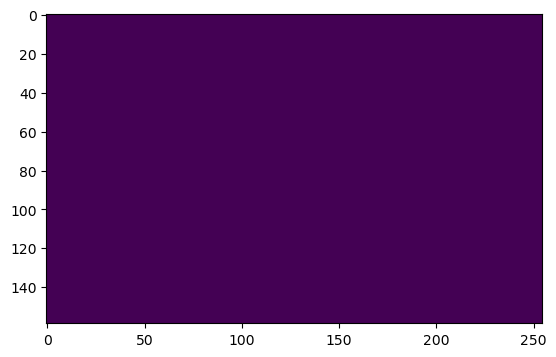

In [17]:
import matplotlib.pyplot as plt
plt.imshow(masks[29])

In [32]:
import importlib
importlib.reload(ra.rfs)
d_rf_params = ra.rfs.rf_fitting_pipeline(
        stas=stas, str_output_dir=chunk_save_dir
    )

Stas shape: torch.Size([424, 159, 255])
Fitting DoG model with 424 cells


  5%|▌         | 50/1000 [00:12<03:55,  4.04it/s]

Epoch 50/1000, Train Loss: 0.0211, Grad Norm: 0.0000
Train R: 0.1449


 10%|█         | 100/1000 [00:24<03:46,  3.97it/s]

Epoch 100/1000, Train Loss: 0.0199, Grad Norm: 0.0000
Train R: 0.1644


...

Epoch 900/1000, Train Loss: 0.0194, Grad Norm: 0.0000
Train R: 0.1916


 95%|█████████▌| 951/1000 [03:57<00:15,  3.21it/s]

Epoch 950/1000, Train Loss: 0.0194, Grad Norm: 0.0000
Train R: 0.1917


100%|██████████| 1000/1000 [04:05<00:00,  4.07it/s]


Epoch 1000/1000, Train Loss: 0.0194, Grad Norm: 0.0000
Train R: 0.1917
Best Train Loss: 0.0194 at Epoch 995
Loaded best state dict.


In [34]:
from skimage.segmentation import flood
def get_signs_peaks(stas):
    # Get peak index of each cell's STA
    n_cells, n_depth, n_height, n_width, n_channels = stas.shape
    peak_idxs = np.argmax(np.abs(stas).reshape(n_cells, -1), axis=1)
    peak_ts, peak_hs, peak_ws, peak_cs = np.unravel_index(peak_idxs, (n_depth, n_height, n_width, n_channels))

    # Collect center pixel timecourse for every channel for final output.
    # timecourses = stas[np.arange(n_cells), :, peak_hs, peak_ws, :]
    
    # Get peak spatial frame [K, H, W].
    spatial_stas = stas[np.arange(n_cells), peak_ts, :, :, peak_cs]
    
    # Collect signs, will save later for On/Off auto classification.
    signs = np.sign(stas[np.arange(n_cells), peak_ts, peak_hs, peak_ws, peak_cs])
    
    # Make them all "ON" i.e. positive peaks
    spatial_stas = spatial_stas * signs[:, np.newaxis, np.newaxis]

    ## Estimate initial sigmas from mask.
    # Make high SNR mask, with threshold of top 10% of values in the peak frame
    thresholds = np.percentile(spatial_stas.reshape(n_cells, -1), 90, axis=1)
    # [K, H, W] >= [K, 1, 1]
    thresholds = thresholds.reshape(-1, 1, 1)
    # [K, H, W] masks
    masks = np.where(spatial_stas >= thresholds, 1, 0)
    
    # Compute contiguous region around peak, and estimate row and col sigmas.
    ls_row_sigmas = []
    ls_col_sigmas = []
    ls_tcs = []
    lowsnr_idxs = []
    for i in range(n_cells):
        mask = masks[i]
        peak_h, peak_w = peak_hs[i], peak_ws[i]

        # Use flood fill to find contiguous region around the peak
        cnt_mask = flood(mask, (peak_h, peak_w), connectivity=1)
        
        # Get timecourses from avg of contiguous region
        h_inds, w_inds = np.where(cnt_mask)
        # [D, C]
        tc = np.mean(stas[i, :, h_inds, w_inds, :], axis=0)
        ls_tcs.append(tc)

        # Get bounding box of contiguous region
        n_cnt_rows = w_inds.max() - w_inds.min()
        n_cnt_cols = h_inds.max() - h_inds.min()
        # If too small, set to default value
        if n_cnt_rows < 2 or n_cnt_cols < 2:
            n_cnt_rows = 4
            n_cnt_cols = 4
            lowsnr_idxs.append(i)
        ls_row_sigmas.append(n_cnt_cols / 2.0)
        ls_col_sigmas.append(n_cnt_rows / 2.0)
    return lowsnr_idxs, signs, peak_cs
lowsnr_idxs, signs, peak_cs = get_signs_peaks(stas)

In [35]:
auto_types = np.array(['Unknown'] * d_rf_params['model'].n_cells)
blue_idxs = np.where(peak_cs == 2)[0]
auto_types[blue_idxs] = 'Blue'
on_idxs = np.where((signs >= 0))[0]
off_idxs = np.where((signs < 0))[0]
on_idxs = np.setdiff1d(on_idxs, blue_idxs)
off_idxs = np.setdiff1d(off_idxs, blue_idxs)
auto_types[on_idxs] = 'On'
auto_types[off_idxs] = 'Off'
auto_types[lowsnr_idxs] = 'LowSNR'

In [36]:
auto_types_file = os.path.join(chunk_save_dir, f'{ss_version}_auto_types.txt')
type_data = np.array(list(zip(d_data['cell_ids'], auto_types)), dtype=object)
np.savetxt(auto_types_file, type_data, fmt='%s', delimiter='\t')
print(f"Auto types saved to {auto_types_file}")

Auto types saved to /home/vyomr/Desktop/data/analysis/20260403C/chunk2/kilosort2.5/kilosort2.5_auto_types.txt


In [5]:
sta_height = stas.shape[2]
ra.sta.write_params_file(
    sta_height, 
    d_data, d_rf_params, chunk_save_dir, ss_version
)

Saving RF params and ISI data to /home/vyomr/Desktop/data/analysis/20260403C/chunk2/kilosort2.5/kilosort2.5.params...
Writing file header.


Writing parameters for each cell: 100%|██████████| 424/424 [00:00<00:00, 2194.55it/s]

Saved to /home/vyomr/Desktop/data/analysis/20260403C/chunk2/kilosort2.5/kilosort2.5.params


In [9]:
importlib.reload(ra.classes.analysis_chunk)

<module 'retinanalysis.classes.analysis_chunk' from '/home/vyomr/Desktop/gitrepos/retinanalysis/src/retinanalysis/classes/analysis_chunk.py'>

In [10]:
ac = ra.classes.analysis_chunk.AnalysisChunk(exp_name, 'chunk2')

Loading VCD from /mnt/Volumes/data-1/analysis/20260403C/chunk2/kilosort2.5 ...
VCD loaded with 440 cells.

['OnP' 'OffP' 'LOnM' 'MOnM' 'OnM' 'BlueOffM' 'LOffM' 'MOffM' 'OffM' 'OnS'
 'OffS' 'SBC' 'BT' 'OnMystery' 'OffMystery' 'OffBoring' 'OnWiggles'
 'OnLarge' 'OffLarge' 'Xmas' 'RB' 'Tufted' 'BlueMystery' 'A1'
 'OnAmacrine ' 'OffAmacrine' 'BlueAmacrine' 'Amacrine' 'InterestingIfTrue'
 'BigMas' 'Spotty' 'Shadow' 'Blobby' 'BluePeaky' 'BadRFFit_ON'
 'BadRFFit_OFF']

Loaded spatial maps for channels [0, 2] and 424 cells of shape (227, 365, 2)
Spatial maps have been padded to align with RF parameters.



In [13]:
ac.df_cell_params['typing_file_0'].value_counts()

typing_file_0
Unknown         184
OffP             52
OnP              49
OffM             42
OffMystery       29
SBC              25
OnM              24
OnMystery         8
BlueMystery       5
BadRFFit_ON       3
BadRFFit_OFF      3
Name: count, dtype: int64

array([<Axes: title={'center': 'BadRFFit_OFF, (n = 3)'}, xlabel='pixels', ylabel='pixels'>,
       <Axes: title={'center': 'BadRFFit_ON, (n = 3)'}, xlabel='pixels', ylabel='pixels'>],
      dtype=object)

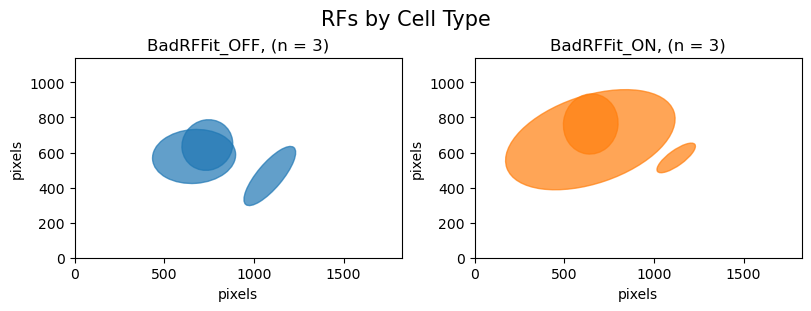

In [12]:
ac.plot_rfs(cell_types=['BadRFFit_ON', 'BadRFFit_OFF', 'BadRFFit_ONOFF'])

In [ ]:
ra.get_ells()